##### Feladat (Példatár 1.10)

Határozzuk meg az alábbi tartó $AC$ és $CB$ részein a keresztmetszet méreteit úgy, hogy a $b2/a2 = b1/a1 = 2$ feltétel mellett hajlításra megfeleljen a tartó! Adatok: $L_1 = 2 ~\mathrm{m}$ , $L_2 = 1 ~\mathrm{m}$ , $L_3 = 4 ~\mathrm{m}$ , $F = 14 ~\mathrm{kN}$ , $σ_\mathrm{meg} = 100 ~\mathrm{MPa}$ .

<img src="img/01.jpg" alt="Feladat" width=450px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
L_1 = 2 # m
L_2 = 1 # m
L_3 = 4 # m
ratio = 2 # 1
F = 14 # kN
sigma_meg = 100 # MPa

# Átváltás N, mm, MPa rendszerbe
L_1 = L_1 * 10**3 # m
L_2 = L_2 * 10**3 # m
L_3 = L_3 * 10**3 # m
F = F * 10**3 # N

##### Szabadtest ábra

<img src="img/02.jpg" alt="Feladat" width=300px>

##### A reakciók

In [3]:
A_x, A_z, B_z = sp.symbols('A_x, A_z, B_z')
x = sp.Symbol('x', positive=True)

##### Egyensúlyi egyenletek

In [4]:
# x irányú erő egyensúly
eq1 = A_x
display(Math(rf'\sum F_x = 0 \quad \longrightarrow \quad {latex(eq1)} = 0'))

# y irányú erő egyensúly
eq2 = A_z - F + B_z
display(Math(rf'\sum F_y = 0 \quad \longrightarrow \quad {latex(eq2)} = 0'))

# z irányú nyomatéki egyensúly
eq3 = -F*L_1 + B_z*(L_1 + L_2 + L_3)
display(Math(rf'\sum M_A = 0 \quad \longrightarrow \quad {latex(eq3)} = 0'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Egyensúlyi egyenletek megoldása

In [5]:
sol = sp.solve([eq1, eq2, eq3], [A_x, A_z, B_z])

A_xsol = sol[A_x]
display(Math(rf'A_x = {latex(A_xsol)} ~ \mathrm{{N}}'))

A_zsol = sol[A_z]
display(Math(rf'A_z = {latex(A_zsol)} ~ \mathrm{{N}}'))

B_zsol = sol[B_z]
display(Math(rf'B_z = {latex(B_zsol)} ~ \mathrm{{N}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Igénybevételek

In [6]:
# 1. szakasz
V_I = A_zsol
Mh_I = -A_zsol*x
display(Latex('1. szakasz:'))
display(Math(rf'V_{{I}} = {latex(V_I)}'))
display(Math(rf'M_{{h,I}} = {latex(Mh_I)}'))

# 2. szakasz
V_II = A_zsol - F
Mh_II = -A_zsol*x + F*(x-L_1)
display(Latex('2. szakasz:'))
display(Math(rf'V_{{II}} = {latex(V_II)}'))
display(Math(rf'M_{{h,II}} = {latex(Mh_II)}'))

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

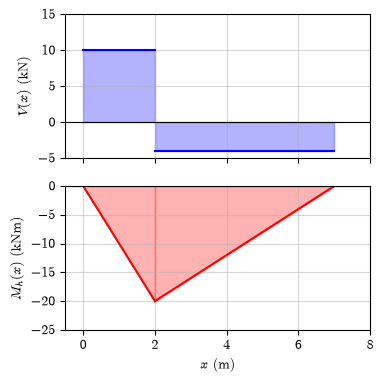

In [7]:
# x koordináták
x1_vals = np.linspace(0, L_1)
x2_vals = np.linspace(L_1, L_1+L_2+L_3)

# Fügvénnyé alakítás
Mh_Inum_fn = sp.lambdify(x, Mh_I, modules="numpy")
Mh_IInum_fn = sp.lambdify(x, Mh_II, modules="numpy")

# Hajlítónyomatéki függvény értékei
Mh_1_vals = Mh_Inum_fn(x1_vals)
Mh_2_vals = Mh_IInum_fn(x2_vals)

# Konstans nyíróerők
V_1_vals = np.full_like(x1_vals, float(V_I))
V_2_vals = np.full_like(x2_vals, float(V_II))

# Ábrázolás
fig, (ax_V, ax_M) = plt.subplots(2, 1, figsize=(10/2.54, 10/2.54), sharex=True)

# Nyíróerő
ax_V.plot(x1_vals*1e-3, V_1_vals*1e-3, color='blue')
ax_V.plot(x2_vals*1e-3, V_2_vals*1e-3, color='blue')
ax_V.fill_between(x1_vals*1e-3, V_1_vals*1e-3, 0, alpha=0.3, color='blue')
ax_V.fill_between(x2_vals*1e-3, V_2_vals*1e-3, 0, alpha=0.3, color='blue')
ax_V.axhline(0, color='black', linewidth=0.8)
ax_V.set_ylabel(r'$V(x) ~ \mathrm{(kN)}$')
ax_V.grid(True, alpha=0.5, zorder=-2)
ax_V.set_ylim(-5, 15)

# Nyomaték
ax_M.plot(x1_vals*1e-3, Mh_1_vals*1e-6, color='red')
ax_M.plot(x2_vals*1e-3, Mh_2_vals*1e-6, color='red')
ax_M.fill_between(x1_vals*1e-3, Mh_1_vals*1e-6, 0, alpha=0.3, color='red')
ax_M.fill_between(x2_vals*1e-3, Mh_2_vals*1e-6, 0, alpha=0.3, color='red')
ax_M.axhline(0, color='black', linewidth=0.8)
ax_M.set_xlabel(r'$x ~ \mathrm{(m)}$')
ax_M.set_ylabel(r'$M_h(x) ~ \mathrm{(kNm)}$')
ax_M.grid(True, alpha=0.5, zorder=-2)
ax_M.set_xlim(-0.5, (L_1+L_2+L_3)*1e-3+1)
ax_M.set_ylim(-25, 0)

plt.tight_layout()
plt.savefig('igenybeveteli_abrak.pdf')

##### Maximális hajlítónyomatékok

In [8]:
# 1. szakasz
Mh_Imax = sp.maximum(sp.Abs(Mh_I), x, sp.Interval(0, L_1))
display(Latex('1. szakasz:'))
display(Math(rf'M_{{h,Imax}} = {latex(Mh_Imax)} ~ \mathrm{{Nmm}}'))

# 2. szakasz
Mh_IImax = sp.maximum(sp.Abs(Mh_II), x, sp.Interval(L_1+L_2, L_1+L_2+L_3))
display(Latex('2. szakasz:'))
display(Math(rf'M_{{h,IImax}} = {latex(Mh_IImax)} ~ \mathrm{{Nmm}}'))

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

##### Szükséges keresztmetszeti tényezők

In [9]:
# Szimbolikus változók
a_1, b_1, a_2, b_2 = sp.symbols('a_1, b_1, a_2, b_2')

b_1 = ratio*a_1
b_2 = ratio*a_2

# 1. szakasz
K_I = a_1*b_1**2/6

# 2. szakasz
K_II = a_2*b_2**2/6

##### Megoldás a keresztmetszeti méretekre, felhasználva a határhelyzetet

In [10]:
# 1. szakasz
sigma_1 = Mh_Imax / K_I # Ébredő feszültség

eq1 = sigma_1 - sigma_meg # Egyenlő a megengedett feszültséggel

sol = sp.solve(eq1, a_1)
a_1sol = sol[0]
display(Math(rf'a_{{1}} = {latex(a_1sol.evalf(5))} ~ \mathrm{{mm}}'))

# 2. szakasz
sigma_2 = Mh_IImax / K_II # Ébredő feszültség

eq2 = sigma_2 - sigma_meg # Egyenlő a megengedett feszültséggel

sol = sp.solve(eq2, a_2)
a_2sol = sol[0]
display(Math(rf'a_{{2}} = {latex(a_2sol.evalf(5))} ~ \mathrm{{mm}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>